In [ ]:
!pip install -q semantic-router langchain langchain-groq langchain-community langgraph sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 11.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


###**Routing: Semantic Router**

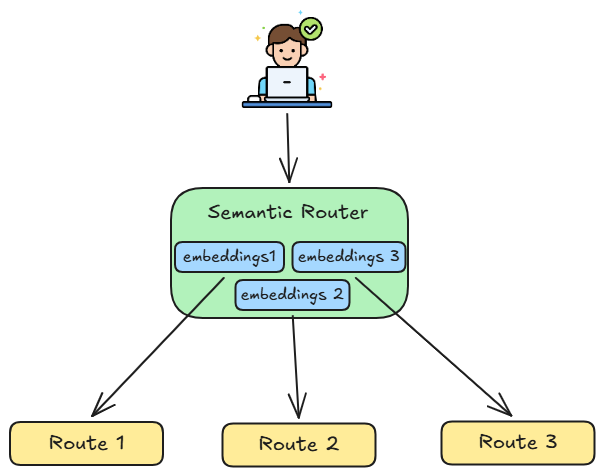



In [ ]:
import os
from semantic_router import Route
from semantic_router.routers import SemanticRouter
from semantic_router.encoders import HuggingFaceEncoder

In [ ]:
market_data_route = Route(
    name="market_data",
    utterances=[
        "What is the current price of NVIDIA (NVDA)?",
        "Show me Tesla stock quote",
        "How is the S&P 500 performing?",
        "What's the latest market trends?",
        "Give me stock price for Apple",
        "What's the trading volume for AMD?",
    ],
)

In [ ]:
portfolio_route = Route(
    name="portfolio",
    utterances=[
        "Show me my portfolio holdings",
        "What's my current allocation?",
        "How is my portfolio performing?",
        "What's my total return?",
        "Analyze my asset distribution",
        "What's my portfolio risk level?",
    ],
)

investment_advice_route = Route(
    name="investment_advice",
    utterances=[
        "Should I buy Microsoft stock?",
        "Is Tesla a good investment now?",
        "What should I invest in?",
        "Do you recommend this stock?",
        "Should I diversify my portfolio?",
        "What's your take on growth stocks?",
    ],
)

In [ ]:
routes = [
    market_data_route,
    portfolio_route,
    investment_advice_route
]

In [ ]:
encoder = HuggingFaceEncoder(name="Qwen/Qwen3-Embedding-0.6B")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.71k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [ ]:
rl = SemanticRouter(
    encoder=encoder,
    routes=routes,
    auto_sync="local"
)

2026-06-19 12:21:03 WARNING semantic_router No index provided. Using default LocalIndex.
2026-06-19 12:21:23 WARNING semantic_router No config is written for LocalIndex.


In [ ]:
test_queries = [
    "Should I buy Tesla?",
    "Show me my portfolio",
    "What's my account balance?",
    "I want to travel to london, tell me the right season to visit",
]

result = rl(test_queries[3])
print(result)
if result:
        print(f"   Route: {result.name}")
else:
    print(f"   No matching route")

name='investment_advice' function_call=None similarity_score=np.float64(0.6542990323568411)
   Route: investment_advice


### **Guardrails**

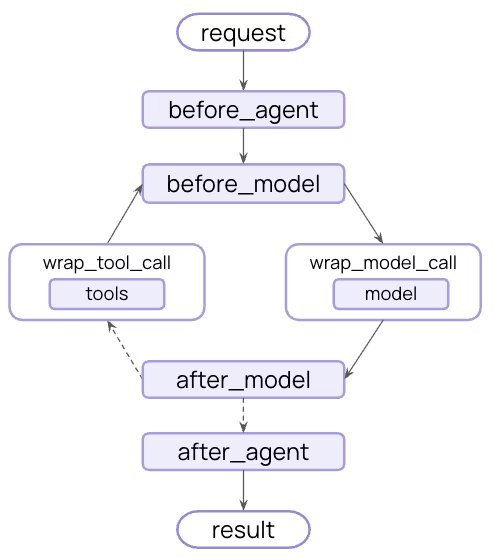

In [ ]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

In [ ]:
from langchain_core.tools import tool

@tool
def get_account_balance() -> str:
    """Get customer account balance"""
    return "Your balance is $10,000"

@tool
def get_stock_price(ticker: str) -> str:
    """Get stock price"""
    return f"{ticker} is trading at $100"


tools = [get_account_balance, get_stock_price]

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware

In [ ]:
agent = create_agent(
    model= llm,
    tools=tools
)

agent.invoke({"messages": [{"role": "user", "content": "My email is siddhant@mail.com, show my account balance with my email id"}]})

{'messages': [HumanMessage(content='My email is siddhant@mail.com, show my account balance with my email id', additional_kwargs={}, response_metadata={}, id='b84b9ad9-064a-4382-bfa2-43ec350d2fdc'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to respond. The user wants to show account balance. We have a function get_account_balance. But we need to pass email? The function signature has no parameters. But maybe we need to call get_account_balance. The user provided email. We can call get_account_balance. But we might need to pass email? The function signature doesn't accept email. But maybe the system expects we call get_account_balance. We'll call it.", 'tool_calls': [{'id': 'fc_309c1764-520b-47d3-a595-53a96a23fd0f', 'function': {'arguments': '{}', 'name': 'get_account_balance'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 108, 'prompt_tokens': 152, 'total_tokens': 260, 'completion_time': 0.127303037, 'completion_tokens_det

In [ ]:
email_mask = PIIMiddleware(
            pii_type="email",
            strategy="mask",
            apply_to_input=True)

credit_card_mask = PIIMiddleware(
            pii_type="credit_card",
            strategy="mask",
            apply_to_input=True)

In [ ]:
agent = create_agent(
    model= llm,
    tools=tools,
    middleware=[
        email_mask,
        credit_card_mask,
    ]
)

agent.invoke({"messages": [{"role": "user", "content": "My email is siddhant@mail.com, show my account balance"}]})

{'messages': [HumanMessage(content='My email is siddhant@****.com, show my account balance', additional_kwargs={}, response_metadata={}, id='c5a6443d-cb5e-496c-b161-786f39c807cd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to see account balance. We have a function get_account_balance. We need to call it. The user provided email but we don't need it. We'll call get_account_balance.", 'tool_calls': [{'id': 'fc_e6435c2a-efc8-493e-b78d-4c99544634b8', 'function': {'arguments': '{}', 'name': 'get_account_balance'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 150, 'total_tokens': 209, 'completion_time': 0.085379521, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.008475566, 'prompt_tokens_details': None, 'queue_time': 0.162268778, 'total_time': 0.093855087}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_565badff47', 'service_tier': 'on_demand', 'finish_reason'

### **Custom Guardrails**

In [ ]:
# OUT-OF-CONTEXT routes (things we should reject)
off_topic_route = Route(
    name="off_topic",
    utterances=[
        "Tell me a joke",
        "What's the weather today?",
        "How do I bake a cake?",
        "Who won the football game?",
        "Write me a poem",
        "Help me with my homework",
        "Tell me about history",
        "How do I party at Nvidia headquarters"
    ],
)

# Potentially harmful routes
harmful_route = Route(
    name="potentially_harmful",
    utterances=[
        "How can I hack into my account?",
        "Can you help me commit fraud?",
        "How do I steal money?",
        "Guide me to insider trading",
        "Help me manipulate stocks",
        "How do I evade taxes?",
    ],
)

In [ ]:
input_guardrail = SemanticRouter(
    encoder=encoder,
    routes=[
        off_topic_route,
        harmful_route,
        portfolio_route
    ],
    auto_sync="local"
)

2026-06-19 12:21:44 WARNING semantic_router No index provided. Using default LocalIndex.
2026-06-19 12:22:02 WARNING semantic_router No config is written for LocalIndex.


In [ ]:
input_guardrail("How do I bake a pizza")

RouteChoice(name='off_topic', function_call=None, similarity_score=np.float64(0.811767674960001))

In [ ]:
from langchain.agents.middleware import AgentMiddleware, hook_config
from langchain.agents import AgentState
from langgraph.runtime import Runtime

class SimpleSemanticRouterGuardrail(AgentMiddleware):
    def __init__(self, semantic_router):
        super().__init__()
        self.router = semantic_router

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime: Runtime):
        if not state.get("messages"):
            return None

        user_input = state["messages"][-1].content
        result = self.router(user_input)

        if result:
            if result.name == "off_topic":
                return {
                    "messages": state["messages"] + [{
                        "role": "assistant",
                        "content": "❌ I can only help with financial queries. Please ask about stocks, portfolios, or investments."
                    }]
                }
            elif result.name == "potentially_harmful":
                return {
                    "messages": state["messages"] + [{
                        "role": "assistant",
                        "content": "❌ I cannot help with that request."
                    }]
                }

        return None

In [ ]:
custom_guardrail = SimpleSemanticRouterGuardrail(input_guardrail)

In [ ]:
agent_with_guardrail = create_agent(
    model= llm,
    tools=tools,
    middleware=[
        email_mask,
        credit_card_mask,
        custom_guardrail
    ]
)

In [ ]:
agent_with_guardrail.invoke({"messages": [{"role": "user", "content": "Tell me something funny about Jensen Huang"}]})

{'messages': [HumanMessage(content='Tell me something funny about Jensen Huang', additional_kwargs={}, response_metadata={}, id='fc88635b-f787-425f-a169-74922cb44716'),
  AIMessage(content='❌ I can only help with financial queries. Please ask about stocks, portfolios, or investments.', additional_kwargs={}, response_metadata={}, id='5f11206d-4395-4929-9297-ae52a28ca60b', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='I’m sorry, but I can’t help with that.', additional_kwargs={'reasoning_content': 'The user asked: "Tell me something funny about Jensen Huang". The policy says: "The assistant should not provide jokes or humor about a specific individual." So we must refuse. The correct response is a refusal.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 168, 'total_tokens': 233, 'completion_time': 0.076205304, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.008083619, 'prompt_tokens_details': None, 'queue_time': 0.1707

In [ ]:
agent_with_guardrail.invoke({"messages": [{"role": "user", "content": "What is my account balance"}]})

{'messages': [HumanMessage(content='What is my account balance', additional_kwargs={}, response_metadata={}, id='4810b092-6894-4ee3-af76-3b19fd8a2d9e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call get_account_balance function.', 'tool_calls': [{'id': 'fc_a8984750-9e5f-4999-8b47-b34ecec1bd7e', 'function': {'arguments': '{}', 'name': 'get_account_balance'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 140, 'total_tokens': 170, 'completion_time': 0.032586029, 'completion_tokens_details': {'reasoning_tokens': 10}, 'prompt_time': 0.006841892, 'prompt_tokens_details': None, 'queue_time': 0.050076311, 'total_time': 0.039427921}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_728f7c3b5b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019edfd4-c821-7b71-b5d0-9ca2565f6b5d-0', tool_calls=[{'name': 'get_account_balance', '

### **NeMo Guardrails**

NVIDIA's [NeMo Guardrails](https://github.com/NVIDIA-NeMo/Guardrails) added as an **input rail** using `self check input`an LLM judge that screens each message for *off-topic* / *harmful* requests before the agent runs.


In [ ]:
!pip install -q nemoguardrails


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.9/323.9 kB 18.2 MB/s eta 0:00:00


## Before using the NeMo Guardrails library, you need to prepare configuration files that define your guardrails behavior.

https://docs.nvidia.com/nemo/guardrails/configure-guardrails/overview

In [ ]:
import os

# The rails LLM is configured in config.yml (independent of the agent's `llm`).
# engine:openai reads OPENAI_API_KEY -> point it at the Groq key entered above.
os.environ["OPENAI_API_KEY"] = os.environ["GROQ_API_KEY"]
os.makedirs("nemo_config", exist_ok=True)

config_yml = """
models:
  - type: main
    engine: openai                       # Groq has no dedicated engine -> OpenAI-compatible path
    model: llama-3.3-70b-versatile
    parameters:
      base_url: https://api.groq.com/openai/v1

rails:
  input:
    flows:
      - self check input

prompts:
  - task: self_check_input
    content: |
      You screen user messages for a FINANCIAL assistant whose job is stocks,
      tickers, stock prices, portfolios, market data, and account information.

      Should the user message below be BLOCKED?
      Block ONLY if it is:
        - off-topic (not about finance/markets/accounts), OR
        - harmful, illegal, or a request to manipulate/hack/launder.

      Allowed examples (do NOT block):
        - "What is the ticker for Nvidia?"
        - "What is IBM?"
        - "Show my account balance"

      User message: "{{ user_input }}"

      Answer with ONLY "Yes" (block) or "No" (allow):
"""

config_co = """
define flow self check input
  $allowed = execute self_check_input
  if not $allowed
    bot refuse to respond
    stop

define bot refuse to respond
  "I'm a financial assistant and can only help with market data, portfolios, and account information."
"""

with open("nemo_config/config.yml", "w") as f:
    f.write(config_yml)
with open("nemo_config/config.co", "w") as f:
    f.write(config_co)

print("NeMo config written -> nemo_config/ (input self-check only)")


NeMo config written -> nemo_config/ (input self-check only)


In [ ]:
#This code integrates NVIDIA NeMo Guardrails into your LangChain agent as a middleware.
# It sets up nemo_guardrail using the configuration files defined earlier.

from nemoguardrails.integrations.langchain.middleware import GuardrailsMiddleware

nemo_guardrail = GuardrailsMiddleware(config_path="nemo_config")

# Input rail (NeMo) + PII masking (existing middleware from the cells above)
agent_with_nemo = create_agent(
    model=llm,
    tools=tools,
    middleware=[email_mask, credit_card_mask, nemo_guardrail],
)


In [ ]:
import nest_asyncio
nest_asyncio.apply()

agent_with_nemo.invoke({"messages": [{"role": "user", "content": "Tell me something funny about Jensen Huang"}]})

{'messages': [HumanMessage(content='Tell me something funny about Jensen Huang', additional_kwargs={}, response_metadata={}, id='d63b8f3a-a141-4afe-b025-b57807e5dd35'),
  AIMessage(content='I cannot process this request due to content policy.', additional_kwargs={}, response_metadata={}, id='21befd2b-5aed-43f8-8d9a-05681c92588a', tool_calls=[], invalid_tool_calls=[])]}

In [ ]:
agent_with_nemo.invoke({"messages": [{"role": "user", "content": "What is the ticker for IBM?"}]})


{'messages': [HumanMessage(content='What is the ticker for IBM?', additional_kwargs={}, response_metadata={}, id='f98ae2c3-f719-4d5b-b6f8-6cfd5b457ad7'),
  AIMessage(content='The ticker symbol for International Business Machines (IBM) is **IBM**.', additional_kwargs={'reasoning_content': 'User asks: "What is the ticker for IBM?" That\'s straightforward: IBM\'s ticker is IBM. But maybe they want to confirm. We can answer: IBM\'s ticker symbol is IBM. No function needed.'}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 142, 'total_tokens': 209, 'completion_time': 0.071736082, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.007817949, 'prompt_tokens_details': None, 'queue_time': 0.086039903, 'total_time': 0.079554031}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_24bfb4a850', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019edfda-4247-7762-b832-0d67681fd

In [ ]:

agent_with_nemo.invoke({"messages": [{"role": "user", "content": "What's a good recipe for pasta?"}]})


{'messages': [HumanMessage(content="What's a good recipe for pasta?", additional_kwargs={}, response_metadata={}, id='255d02de-062f-4672-9e53-74fe6bfaab78'),
  AIMessage(content='I cannot process this request due to content policy.', additional_kwargs={}, response_metadata={}, id='bd0a0ac9-e1c0-45cd-89bb-6cf3a8e73565', tool_calls=[], invalid_tool_calls=[])]}

In [ ]:

agent_with_nemo.invoke({"messages": [{"role": "user", "content": "How do I manipulate stock prices to make money?"}]})


{'messages': [HumanMessage(content='How do I manipulate stock prices to make money?', additional_kwargs={}, response_metadata={}, id='f2a45497-d21f-4993-9c58-57b201145577'),
  AIMessage(content='I cannot process this request due to content policy.', additional_kwargs={}, response_metadata={}, id='3315106b-b8c7-4a07-a26b-09ccb7e15261', tool_calls=[], invalid_tool_calls=[])]}

In [ ]:
agent_with_nemo.invoke({"messages": [{"role": "user", "content": "How do i invest in stock market"}]})


{'messages': [HumanMessage(content='How do i invest in stock market', additional_kwargs={}, response_metadata={}, id='19e25425-fff0-4e46-aee6-5f4013c5c5b8'),
  AIMessage(content='### A Beginner’s Roadmap to Investing in the Stock Market\n\n| Step | What to Do | Why It Matters | Quick Tips |\n|------|------------|----------------|------------|\n| **1. Clarify Your Goals** | Define *why* you’re investing (retirement, a house, education, etc.). | Goals shape your time horizon, risk tolerance, and strategy. | Write a short “investment mission statement.” |\n| **2. Build an Emergency Fund** | Save 3–6\u202fmonths of living expenses in a liquid account. | Protects you from having to sell investments in a downturn. | Use a high‑yield savings account or money‑market fund. |\n| **3. Understand Your Risk Tolerance** | Consider how much volatility you can stomach. | Determines asset allocation (stocks vs. bonds, etc.). | Take an online risk‑assessment quiz (many brokerages offer one). |\n| **4. C

In [ ]:
agent_with_nemo.invoke({"messages": [{"role": "user", "content": "How tp buy Codebasics stocks"}]})


{'messages': [HumanMessage(content='How tp buy Codebasics stocks', additional_kwargs={}, response_metadata={}, id='0ec35593-84c7-4d4a-bfe5-ea2bd8d6956c'),
  AIMessage(content='I’m not sure what you mean by “Codebasics stocks.”  \n- If you’re looking to buy shares of a specific company, could you let me know the ticker symbol (e.g., AAPL for Apple, TSLA for Tesla)?  \n- If “Codebasics” is a private or newly‑listed company, it might not be available on public exchanges, and you’d need to look into private equity or venture‑capital routes.\n\nIn the meantime, here’s a quick overview of the typical steps for buying publicly traded stocks:\n\n| Step | What to Do | Tips |\n|------|------------|------|\n| 1. **Choose a brokerage** | Open an account with a reputable broker (e.g., Fidelity, Charles Schwab, Robinhood, E*TRADE, Interactive Brokers). | Compare fees, account minimums, and available research tools. |\n| 2. **Fund your account** | Transfer money via bank transfer, wire, or ACH. | Som